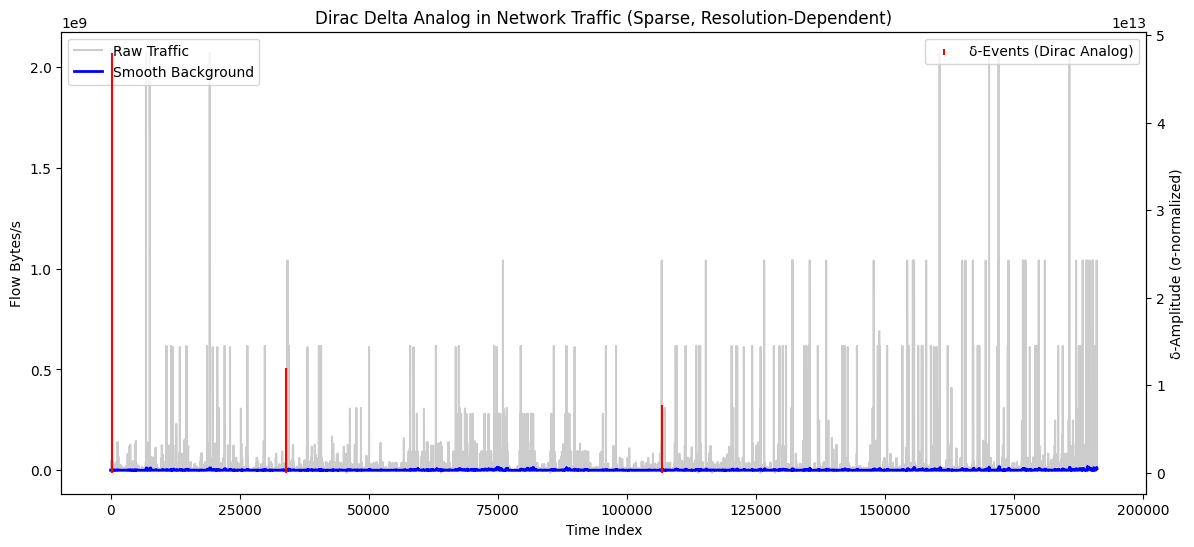

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
path = "Friday-WorkingHours-Morning.pcap_ISCX.csv"
df = pd.read_csv(path)

# --------------------------------------------------
# SELECT SIGNAL (CONTINUOUS TRAFFIC FEATURE)
# --------------------------------------------------
signal_col = "Flow Bytes/s"   # try also: "Flow Packets/s"
df = df[[signal_col]].dropna()

x = df[signal_col].values

# --------------------------------------------------
# PARAMETERS (RESOLUTION CONTROL)
# --------------------------------------------------
WINDOW = 200        # coarse-graining scale
K = 3               # sigma threshold

# --------------------------------------------------
# SMOOTH BACKGROUND
# --------------------------------------------------
mu = pd.Series(x).rolling(WINDOW).mean().values
sigma = pd.Series(x).rolling(WINDOW).std().values

# avoid division issues
sigma[sigma == 0] = 1e-6
mu[np.isnan(mu)] = 0
sigma[np.isnan(sigma)] = 1e-6

# --------------------------------------------------
# δ-EVENT DETECTION
# --------------------------------------------------
delta_event = np.abs(x - mu) > K * sigma

# --------------------------------------------------
# DIRAC DELTA ANALOG (DENSE)
# --------------------------------------------------
delta_amplitude = np.abs(x - mu) / sigma
delta_dense = delta_event * delta_amplitude

# --------------------------------------------------
# δ-THINNING (ISOLATED IMPULSES)
# --------------------------------------------------
# keep only local maxima separated by WINDOW
peaks, _ = find_peaks(delta_dense, distance=WINDOW)

delta_sparse = np.zeros_like(delta_dense)
delta_sparse[peaks] = delta_dense[peaks]

# --------------------------------------------------
# PLOTTING (CORRECT SCALING)
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14,6))

# raw traffic + smooth background
ax1.plot(x, color="gray", alpha=0.4, label="Raw Traffic")
ax1.plot(mu, color="blue", linewidth=2, label="Smooth Background")
ax1.set_ylabel("Flow Bytes/s")
ax1.set_xlabel("Time Index")

# delta impulses on second axis
ax2 = ax1.twinx()
ax2.stem(delta_sparse,
         linefmt='r-',
         markerfmt=' ',
         basefmt=' ',
         label="δ-Events (Dirac Analog)")
ax2.set_ylabel("δ-Amplitude (σ-normalized)")

# legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Dirac Delta Analog in Network Traffic (Sparse, Resolution-Dependent)")
plt.show()


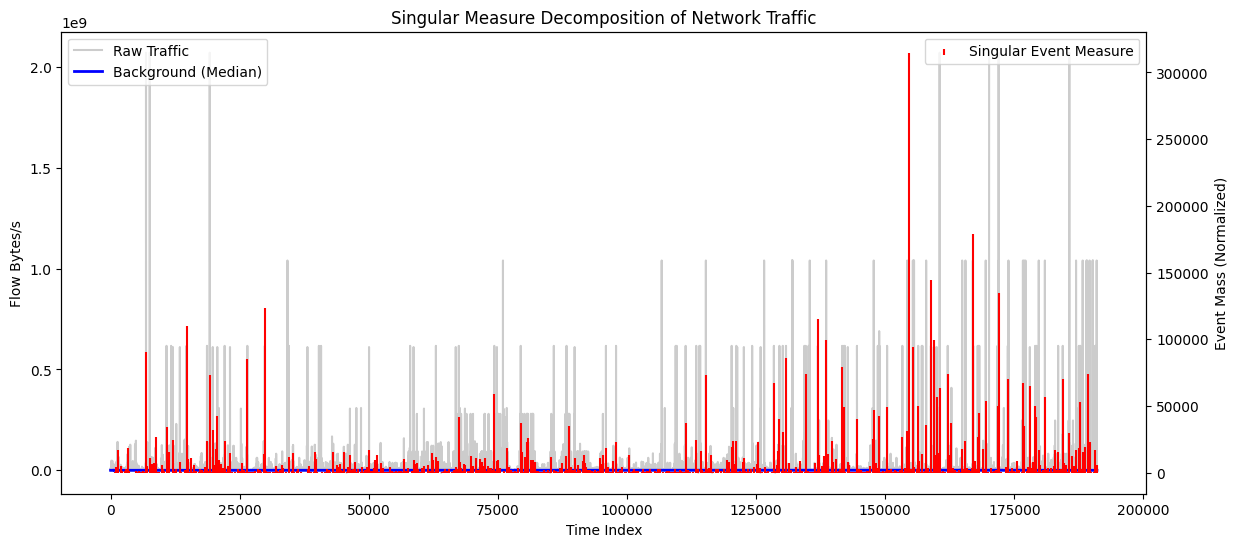

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
path = "Friday-WorkingHours-Morning.pcap_ISCX.csv"
df = pd.read_csv(path)

signal_col = "Flow Bytes/s"
x = df[signal_col].dropna().values
N = len(x)

# --------------------------------------------------
# PARAMETERS (RESOLUTION CONTROL)
# --------------------------------------------------
BACKGROUND_WINDOW = 500
EVENT_WINDOW = 200
K = 3
EPS = 1e-6   # hard regularization floor

# --------------------------------------------------
# TRAVERSAL 1: ROBUST BACKGROUND (ABSOLUTELY CONTINUOUS)
# --------------------------------------------------
mu = pd.Series(x).rolling(BACKGROUND_WINDOW).median().values

# true MAD about median
mad = (
    pd.Series(x)
    .rolling(BACKGROUND_WINDOW)
    .apply(lambda v: np.median(np.abs(v - np.median(v))), raw=True)
    .values
)

sigma = 1.4826 * mad  # consistency with Gaussian scale

# regularization
mu[np.isnan(mu)] = np.nanmedian(mu)
sigma[np.isnan(sigma)] = np.nanmedian(sigma)
sigma = np.maximum(sigma, EPS)

# --------------------------------------------------
# TRAVERSAL 2: DEVIATION FIELD
# --------------------------------------------------
z = (x - mu) / sigma
z[np.isnan(z)] = 0

support = np.abs(z) > K

# --------------------------------------------------
# TRAVERSAL 3: SINGULAR MEASURE EXTRACTION
# --------------------------------------------------
event_signal = np.zeros_like(z)

i = 0
while i < N:
    if support[i]:
        start = i
        while i < N and support[i]:
            i += 1
        end = i

        # normalized event mass (resolution-aware)
        mass = np.sum(np.abs(z[start:end])) / (end - start)

        peak = start + np.argmax(np.abs(z[start:end]))
        event_signal[peak] = mass
    else:
        i += 1

# isolate events
peaks, _ = find_peaks(event_signal, distance=EVENT_WINDOW)

delta_measure = np.zeros_like(event_signal)
delta_measure[peaks] = event_signal[peaks]

# remove undefined boundary region
delta_measure[:BACKGROUND_WINDOW] = 0

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(x, color="gray", alpha=0.4, label="Raw Traffic")
ax1.plot(mu, color="blue", linewidth=2, label="Background (Median)")
ax1.set_ylabel("Flow Bytes/s")
ax1.set_xlabel("Time Index")

ax2 = ax1.twinx()
ax2.stem(delta_measure,
         linefmt='r-',
         markerfmt=' ',
         basefmt=' ',
         label="Singular Event Measure")
ax2.set_ylabel("Event Mass (Normalized)")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Singular Measure Decomposition of Network Traffic")
plt.show()
